## Function 2: Explore Spatial Properties 🧭

In this notebook, you'll learn how to build the `explore_properties()` function step by step. This is like inspecting a spatial dataset to understand its coordinate system, extent, geometry types, and structure before doing any GIS analysis.

### 🎯 What This Function Does
- Extract Coordinate Reference System (CRS) information
- Calculate spatial bounds (bounding box/extent)
- Identify geometry types in datasets
- Access GeoDataFrame properties and metadata
- Build dictionary outputs for spatial summaries

### 🔧 Function Signature
```python
def explore_properties(gdf):
    """
    Args:
        gdf (geopandas.GeoDataFrame): Input spatial dataset
    
    Returns:
        dict: A dictionary summarizing key spatial properties
    """
```

### 📍 Where This Function Goes:
**Target File**: `src/geopandas_basics.py`  
**Function Name**: `explore_properties()`  
**Replace**: The placeholder function with your working code

---

### ⚙️ Step 0: Select the Correct Python Kernel

Before running any cells, make sure the notebook is using the correct Python environment.

**Check the kernel in the top-right corner of the notebook.**

The correct Python environment is **python-gis-development (.venv)**  
It may appear with a Python version, for example:  
**python-gis-development (3.11.15) (Python 3.11.15) .venv/bin/python**



If the kernel is **python-gis-development (.venv)**, you can start running cells below.

Steps to select the correct kernel:
1. Click on the kernel (top right corner of the notebook) if it is not **python-gis-development (.venv)** or if it says "Select Kernel"
2. Select **python-gis-development (.venv)**
3. If you do not see the kernel in the list, click on "Select Another Kernel..."  
    a. Click on Python Environments...   
    b. Select **python-gis-development (.venv)**

Once the correct kernel is selected, you can start running cells below.

### 📚 Step 1: Load Data to Explore

Let's load our spatial data first:

In [1]:
import geopandas as gpd
import numpy as np
from typing import Dict, Any

# Load datasets
cities = gpd.read_file('../../data/cities/ne_cities_us.geojson')
ecoregions = gpd.read_file('../../data/ecoregions/epa_level3_western_us.geojson')
parks = gpd.read_file('../../data/protected_areas/national_parks_major.geojson')

print("✅ Loaded:")
print(f"   Cities: {len(cities)} features")
print(f"   Ecoregions: {len(ecoregions)} features")
print(f"   Parks: {len(parks)} features")

✅ Loaded:
   Cities: 281 features
   Ecoregions: 188 features
   Parks: 37 features


### 🗺️ Step 2: Understanding CRS (Coordinate Reference System)

Note: `EPSG:4326` is WGS84 (lat/lon) - the most common geographic CRS!

**💡 This will be used in our function!**

In [2]:
# 💡 Access CRS with .crs property
print("CRS Information:")
print(f"Cities CRS: {cities.crs}")
print(f"Ecoregions CRS: {ecoregions.crs}")
print(f"Parks CRS: {parks.crs}")
print()

# Check if CRS is defined
print(f"Cities has CRS? {cities.crs is not None}")

# This is how we'll store CRS in our dictionary
properties = {}
properties['crs'] = cities.crs
print(f"\nStored in dict: {properties['crs']}")

CRS Information:
Cities CRS: EPSG:4326
Ecoregions CRS: EPSG:4326
Parks CRS: EPSG:4326

Cities has CRS? True

Stored in dict: EPSG:4326


### 📐 Step 3: Understanding Spatial Bounds (Extent)

**💡 This will be used in our function!**

In [3]:
# 💡 Get bounds with .total_bounds - returns [minx, miny, maxx, maxy]
bounds = cities.total_bounds
print(f"Cities bounds: {bounds}")
print(f"Type: {type(bounds)}")
print()

# Break down the bounds
minx, miny, maxx, maxy = bounds
print(f"Min Longitude (West): {minx}")
print(f"Min Latitude (South): {miny}")
print(f"Max Longitude (East): {maxx}")
print(f"Max Latitude (North): {maxy}")
print()

# 💡 Convert to list for our dictionary (numpy arrays can't be JSON serialized)
bounds_list = bounds.tolist()
print(f"As list: {bounds_list}")
print(f"Type: {type(bounds_list)}")

Cities bounds: [-158.0236209    21.30342908  -70.2455274    61.21400427]
Type: <class 'numpy.ndarray'>

Min Longitude (West): -158.0236209
Min Latitude (South): 21.30342908415294
Max Longitude (East): -70.2455274
Max Latitude (North): 61.21400426552339

As list: [-158.0236209, 21.30342908415294, -70.2455274, 61.21400426552339]
Type: <class 'list'>


### 🗺️ Step 4: Visualization 1 - Bounding Box

Let's **visualize** what bounds/extent means by drawing a bounding box around our data.  
Bounds define the minimum rectangle that contains ALL features. This is useful for:
- Setting map extent
- Checking data coverage
- Detecting outliers (features far from main cluster)

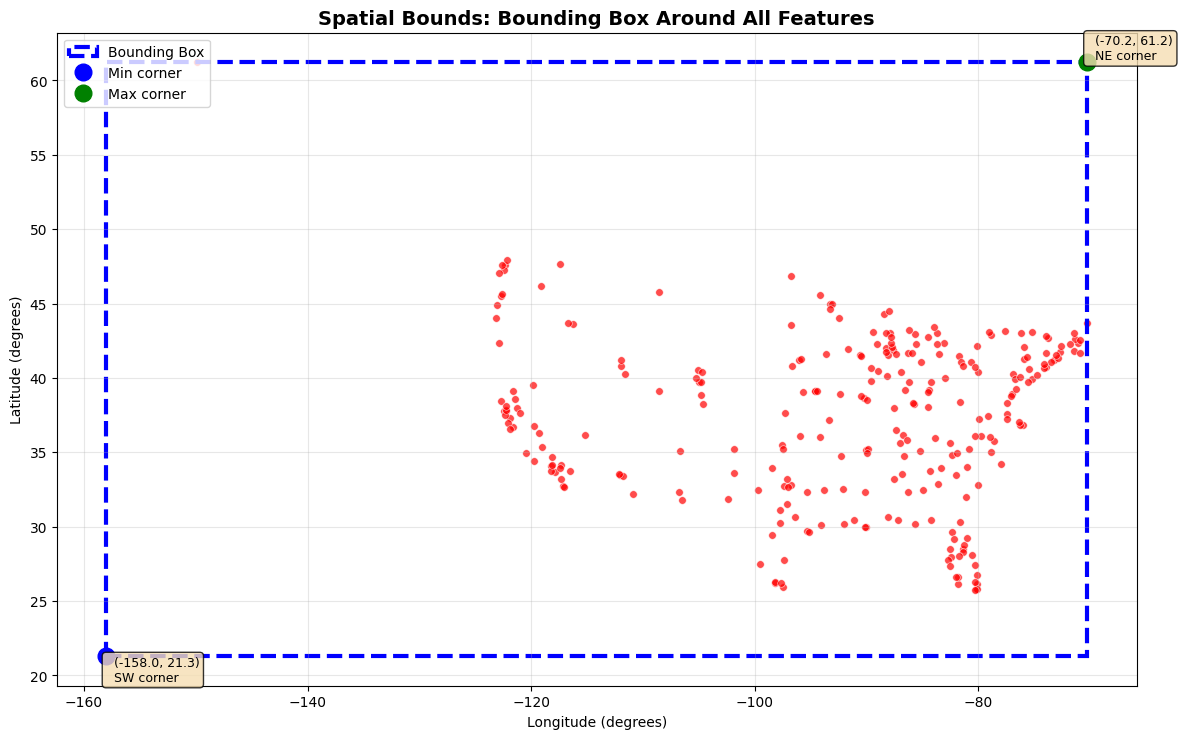

🎯 Bounds represent the rectangular extent:
   Width: 87.78° longitude
   Height: 39.91° latitude


In [4]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(12, 8))

# Plot the data
cities.plot(ax=ax, color='red', markersize=30, alpha=0.7, edgecolor='white', linewidth=0.5)

# Get bounds
minx, miny, maxx, maxy = cities.total_bounds

# Add bounding box rectangle
bbox = Rectangle((minx, miny), 
                maxx - minx, 
                maxy - miny,
                linewidth=3, 
                edgecolor='blue', 
                facecolor='none', 
                linestyle='--',
                label='Bounding Box')
ax.add_patch(bbox)

# Annotate the corners
ax.plot(minx, miny, 'bo', markersize=12, label='Min corner')
ax.plot(maxx, maxy, 'go', markersize=12, label='Max corner')

# Add corner labels
ax.text(minx, miny, f'  ({minx:.1f}, {miny:.1f})\n  SW corner', 
       fontsize=9, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
ax.text(maxx, maxy, f'  ({maxx:.1f}, {maxy:.1f})\n  NE corner', 
       fontsize=9, verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

ax.set_title("Spatial Bounds: Bounding Box Around All Features", fontsize=14, fontweight='bold')
ax.set_xlabel("Longitude (degrees)")
ax.set_ylabel("Latitude (degrees)")
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("🎯 Bounds represent the rectangular extent:")
print(f"   Width: {maxx - minx:.2f}° longitude")
print(f"   Height: {maxy - miny:.2f}° latitude")

### 🗺️ Step 5: Visualization 2 - Geometry Type Distribution

Let's visualize what geometry types exist in our datasets:


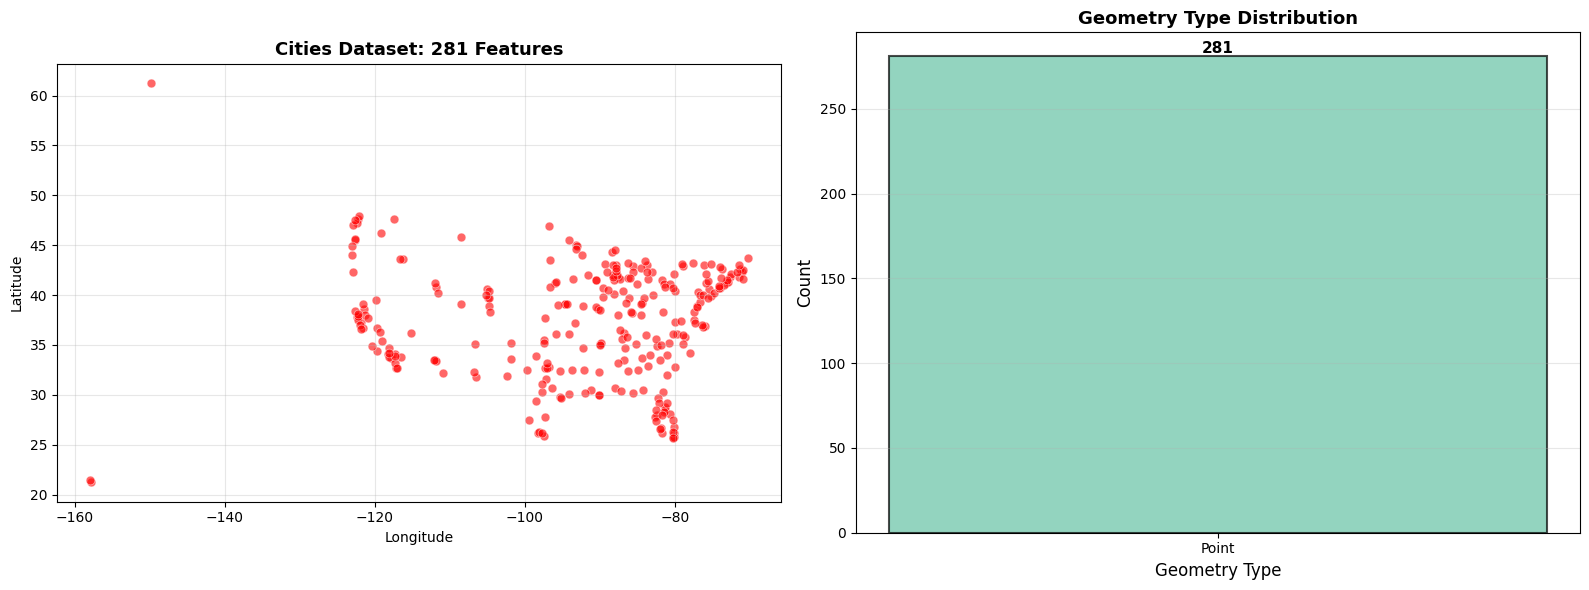

📊 Geometry type distribution:
   Point: 281 features (100.0%)


In [5]:
# Count geometry types in cities dataset
geom_counts = cities.geometry.geom_type.value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# LEFT: Show the spatial data
cities.plot(ax=ax1, color='red', markersize=40, alpha=0.6, edgecolor='white', linewidth=0.5)
ax1.set_title(f"Cities Dataset: {len(cities)} Features", fontsize=13, fontweight='bold')
ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")
ax1.grid(True, alpha=0.3)

# RIGHT: Show geometry type distribution
colors = plt.cm.Set2(range(len(geom_counts)))
bars = ax2.bar(geom_counts.index, geom_counts.values, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax2.set_xlabel("Geometry Type", fontsize=12)
ax2.set_ylabel("Count", fontsize=12)
ax2.set_title("Geometry Type Distribution", fontsize=13, fontweight='bold')
ax2.grid(True, axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("📊 Geometry type distribution:")
for geom_type, count in geom_counts.items():
    print(f"   {geom_type}: {count} features ({count/len(cities)*100:.1f}%)")

### 🔷 Step 6: Identifying Geometry Types

**💡 This will be used in our function!**

**Common Geometry Types:**
- **Point**: Single location (cities, landmarks)
- **LineString**: Connected line (roads, rivers)
- **Polygon**: Closed area (countries, parks, ecoregions)
- **Multi-***: Multiple geometries (MultiPoint, MultiLineString, MultiPolygon)

In [6]:
# 💡 Get geometry types with .geom_type
print("Cities geometry types:")
print(cities.geometry.geom_type.head())
print()

# 💡 Get unique geometry types
unique_types = cities.geometry.geom_type.unique()
print(f"Unique types (numpy array): {unique_types}")
print(f"Type: {type(unique_types)}")
print()

# 💡 Convert to list for our dictionary
types_list = unique_types.tolist()
print(f"As list: {types_list}")
print()

# Check all datasets
print("All datasets:")
print(f"Cities: {cities.geometry.geom_type.unique().tolist()}")
print(f"Ecoregions: {ecoregions.geometry.geom_type.unique().tolist()}")
print(f"Parks: {parks.geometry.geom_type.unique().tolist()}")

Cities geometry types:
0    Point
1    Point
2    Point
3    Point
4    Point
dtype: str

Unique types (numpy array): <StringArray>
['Point']
Length: 1, dtype: str
Type: <class 'pandas.arrays.StringArray'>

As list: ['Point']

All datasets:
Cities: ['Point']
Ecoregions: ['Polygon']
Parks: ['Polygon']


### 🔢 Step 7: Feature Counts and Column Information

**💡 This will be used in our function!**

In [7]:
# 💡 Feature count is just len()
feature_count = len(cities)
print(f"Feature count: {feature_count}")
print()

# 💡 Get column names with .columns
columns = cities.columns
print(f"Columns (Index object): {columns}")
print(f"Type: {type(columns)}")
print()

# 💡 Convert to list for our dictionary
columns_list = columns.tolist()
print(f"As list: {columns_list}")
print(f"Number of columns: {len(columns_list)}")

Feature count: 281

Columns (Index object): Index(['name', 'country', 'state_province', 'population', 'latitude',
       'longitude', 'geometry'],
      dtype='str')
Type: <class 'pandas.Index'>

As list: ['name', 'country', 'state_province', 'population', 'latitude', 'longitude', 'geometry']
Number of columns: 7


### ✅ Step 8: Checking Geometry Validity

**💡 Bonus feature for our function!**

In [8]:
# 💡 Check if all geometries are valid
print("Checking geometry validity:")
print(f"Cities - all valid? {cities.geometry.is_valid.all()}")
print(f"Ecoregions - all valid? {ecoregions.geometry.is_valid.all()}")
print(f"Parks - all valid? {parks.geometry.is_valid.all()}")
print()

# 💡 Handle empty GeoDataFrames
if len(cities) > 0:
    has_valid = cities.geometry.is_valid.all()
else:
    has_valid = True  # Empty dataset is considered valid

print(f"Has valid geometries: {has_valid}")

Checking geometry validity:
Cities - all valid? True
Ecoregions - all valid? True
Parks - all valid? True

Has valid geometries: True


### 🧩 Step 9: Building the Complete Dictionary

**💡 This shows the final structure!**

In [9]:
# 💡 Build a complete properties dictionary
properties = {}

# CRS
properties['crs'] = cities.crs

# Bounds
if len(cities) > 0:
    properties['bounds'] = cities.total_bounds.tolist()
else:
    properties['bounds'] = [np.nan, np.nan, np.nan, np.nan]

# Geometry types
if len(cities) > 0:
    properties['geometry_types'] = cities.geometry.geom_type.unique().tolist()
else:
    properties['geometry_types'] = []

# Feature count
properties['feature_count'] = len(cities)

# Columns
properties['columns'] = cities.columns.tolist()

# Validity check
properties['has_valid_geometries'] = cities.geometry.is_valid.all() if len(cities) > 0 else True

print("Complete properties dictionary:")
for key, value in properties.items():
    print(f"  {key}: {value}")

Complete properties dictionary:
  crs: EPSG:4326
  bounds: [-158.0236209, 21.30342908415294, -70.2455274, 61.21400426552339]
  geometry_types: ['Point']
  feature_count: 281
  columns: ['name', 'country', 'state_province', 'population', 'latitude', 'longitude', 'geometry']
  has_valid_geometries: True


### 🏗️ Step 10: Building the Complete Function

Now let's put everything together into a reusable function. This is what you will implement in `src/geopandas_basics.py`.

In [10]:
import geopandas as gpd
import numpy as np
from typing import Dict, Any

def explore_properties(gdf: gpd.GeoDataFrame) -> Dict[str, Any]:
    """
    Analyze and extract key spatial properties from a GeoDataFrame.
    
    Provides comprehensive exploration of:
    - Coordinate Reference System (CRS)
    - Spatial bounds (extent)
    - Geometry types present
    - Feature count and basic statistics
    
    Args:
        gdf: Input GeoDataFrame to explore
        
    Returns:
        Dictionary containing spatial properties:
        - 'crs': CRS object or None
        - 'bounds': [minx, miny, maxx, maxy] or [nan, nan, nan, nan] if empty
        - 'geometry_types': List of unique geometry types
        - 'feature_count': Number of features
        - 'columns': List of attribute column names
        - 'has_valid_geometries': Boolean indicating if all geometries are valid
        
    Example:
        >>> props = explore_properties(gdf)
        >>> print(f"CRS: {props['crs']}")
        >>> print(f"Bounds: {props['bounds']}")
        >>> print(f"Geometry types: {props['geometry_types']}")
    """
    properties = {}
    
    # Extract CRS (handle empty GeoDataFrames without geometry column)
    try:
        properties['crs'] = gdf.crs
    except AttributeError:
        # Empty GeoDataFrame without geometry column has no CRS
        properties['crs'] = None
    
    # Extract bounds (total_bounds returns [minx, miny, maxx, maxy])
    if len(gdf) > 0:
        bounds = gdf.total_bounds
        properties['bounds'] = bounds.tolist()
    else:
        properties['bounds'] = [np.nan, np.nan, np.nan, np.nan]
    
    # Extract geometry types
    if len(gdf) > 0:
        geometry_types = gdf.geometry.geom_type.unique().tolist()
    else:
        geometry_types = []
    properties['geometry_types'] = geometry_types
    
    # Feature count
    properties['feature_count'] = len(gdf)
    
    # Column information
    properties['columns'] = gdf.columns.tolist()
    
    # Additional useful properties
    try:
        properties['has_valid_geometries'] = gdf.geometry.is_valid.all() if len(gdf) > 0 else True
    except AttributeError:
        # No geometry column
        properties['has_valid_geometries'] = True
    
    return properties

### ✨ Step 11: Test Your Function

Let's test our complete function with various datasets:

In [11]:
# Test 1: Explore cities (Points)
print("Test 1: Cities (Points)")
city_props = explore_properties(cities)
print(f"✅ CRS: {city_props['crs']}")
print(f"✅ Bounds: {city_props['bounds']}")
print(f"✅ Geometry types: {city_props['geometry_types']}")
print(f"✅ Feature count: {city_props['feature_count']}")
print(f"✅ Columns ({len(city_props['columns'])}): {city_props['columns'][:3]}...")
print(f"✅ Valid geometries: {city_props['has_valid_geometries']}")
print()

# Test 2: Explore ecoregions (Polygons)
print("Test 2: Ecoregions (Polygons)")
eco_props = explore_properties(ecoregions)
print(f"✅ CRS: {eco_props['crs']}")
print(f"✅ Bounds: {eco_props['bounds']}")
print(f"✅ Geometry types: {eco_props['geometry_types']}")
print(f"✅ Feature count: {eco_props['feature_count']}")
print()

# Test 3: Explore parks (Polygons)
print("Test 3: National Parks")
park_props = explore_properties(parks)
print(f"✅ CRS: {park_props['crs']}")
print(f"✅ Feature count: {park_props['feature_count']}")
print(f"✅ Geometry types: {park_props['geometry_types']}")
print()

# Test 4: Empty GeoDataFrame
print("Test 4: Empty GeoDataFrame")
empty_gdf = gpd.GeoDataFrame()
empty_props = explore_properties(empty_gdf)
print(f"✅ Feature count: {empty_props['feature_count']}")
print(f"✅ Bounds: {empty_props['bounds']}")
print(f"✅ Geometry types: {empty_props['geometry_types']}")
print(f"✅ Valid: {empty_props['has_valid_geometries']}")
print()

print("🎉 All tests passed! Function is working correctly!")

Test 1: Cities (Points)
✅ CRS: EPSG:4326
✅ Bounds: [-158.0236209, 21.30342908415294, -70.2455274, 61.21400426552339]
✅ Geometry types: ['Point']
✅ Feature count: 281
✅ Columns (7): ['name', 'country', 'state_province']...
✅ Valid geometries: True

Test 2: Ecoregions (Polygons)
✅ CRS: EPSG:4326
✅ Bounds: [-124.73314545495546, 28.972099999904277, -95.57986933515103, 49.002325592594666]
✅ Geometry types: ['Polygon']
✅ Feature count: 188

Test 3: National Parks
✅ CRS: EPSG:4326
✅ Feature count: 37
✅ Geometry types: ['Polygon']

Test 4: Empty GeoDataFrame
✅ Feature count: 0
✅ Bounds: [nan, nan, nan, nan]
✅ Geometry types: []
✅ Valid: True

🎉 All tests passed! Function is working correctly!


### 🧪 Step 12: Verify with Pytest

Test your entire function to verify your implementation in `src/geopandas_basics.py` by running the following line in the terminal

```bash
uv run pytest tests/test_geopandas_basics.py::TestExploreProperties -v
```

**⚠️ IMPORTANT: Make sure this passes before you move on!**

---

### 🔑 Key Learning Points

- **`.crs`** gives you the coordinate reference system for a GeoDataFrame
- **`.total_bounds`** returns the spatial extent as `[minx, miny, maxx, maxy]`
- **`.geom_type.unique()`** helps identify the geometry types in a dataset
- **`len(gdf)`** gives the feature count
- **`.columns.tolist()`** converts attribute column names into a regular Python list
- **`.is_valid.all()`** checks whether all geometries are valid
- Building a **dictionary summary** makes spatial exploration results easy to reuse